<a href="https://colab.research.google.com/github/HansMiku/finalprojectSML/blob/main/crop_diversity_forecasting.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Crop Diversity Forecasting

This notebook implements the complete workflow for forecasting the next-year municipal Simpson Diversity Index (SDI) from SIDRA/IBGE Table 5457 data.

It performs, in sequence:

1. automatic input-folder detection;
2. data preparation and crop harmonization;
3. SDI and temporal-feature construction;
4. chronological model selection using training and validation periods;
5. training and validation curves for every implemented approach;
6. final retraining and one-time test evaluation;
7. model interpretation and export of final results.

The four source spreadsheets must be stored together. No path needs to be edited. Temporary files are kept in the Colab runtime, and the Google Drive folder receives only one final file: `sdi_ml_results.zip`.

The common modeling sample starts in 2001 because 1999 data are not available for constructing lagged variables for the 2000 transition. Basic and expanded models therefore use the same complete sample.

Persistence is a non-trainable baseline. Its curve reports training-period and validation-period reference errors across the same expanding temporal windows used for the trainable models.


In [4]:
import importlib.util
import subprocess
import sys

REQUIRED_PACKAGES = {
    "openpyxl": "openpyxl",
    "pyarrow": "pyarrow",
    "xgboost": "xgboost",
    "tensorflow": "tensorflow",
}
missing_packages = [
    package_name
    for module_name, package_name in REQUIRED_PACKAGES.items()
    if importlib.util.find_spec(module_name) is None
]
if missing_packages:
    subprocess.check_call(
        [sys.executable, "-m", "pip", "install", "-q", *missing_packages]
    )


In [5]:
from __future__ import annotations

import gc
import json
import platform
import random
import re
import shutil
import unicodedata
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn
import tensorflow as tf
import xgboost as xgb
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

SEED = 42
PERMUTATION_SAMPLE_SIZE = 5_000
PERMUTATION_REPEATS = 5

random.seed(SEED)
np.random.seed(SEED)
tf.keras.utils.set_random_seed(SEED)
try:
    tf.config.experimental.enable_op_determinism()
except Exception:
    pass

EXPECTED_FILES = [
    "tabela5457-2000-2006.xlsx",
    "tabela5457-2007-2013.xlsx",
    "tabela5457-2014-2020.xlsx",
    "tabela5457-2021-2024.xlsx",
]

OVERLAPPING_COFFEE_COLUMNS = {
    "Café (em grão) Arábica",
    "Café (em grão) Canephora",
}

PRODUCT_TRANSLATIONS = {
    "Abacate": "Avocado",
    "Abacaxi*": "Pineapple",
    "Açaí": "Acai",
    "Alfafa fenada": "Alfalfa hay",
    "Algodão arbóreo (em caroço)": "Tree cotton",
    "Algodão herbáceo (em caroço)": "Herbaceous cotton",
    "Alho": "Garlic",
    "Amendoim (em casca)": "Peanut",
    "Arroz (em casca)": "Rice",
    "Aveia (em grão)": "Oats",
    "Azeitona": "Olive",
    "Banana (cacho)": "Banana",
    "Batata-doce": "Sweet potato",
    "Batata-inglesa": "Potato",
    "Borracha (látex coagulado)": "Rubber, coagulated latex",
    "Borracha (látex líquido)": "Rubber, liquid latex",
    "Cacau (em amêndoa)": "Cocoa beans",
    "Café (em grão) Total": "Coffee beans, total",
    "Café (em grão) Arábica": "Arabica coffee beans",
    "Café (em grão) Canephora": "Canephora coffee beans",
    "Caju": "Cashew fruit",
    "Cana-de-açúcar": "Sugarcane",
    "Cana para forragem": "Forage cane",
    "Caqui": "Persimmon",
    "Castanha de caju": "Cashew nuts",
    "Cebola": "Onion",
    "Centeio (em grão)": "Rye",
    "Cevada (em grão)": "Barley",
    "Chá-da-índia (folha verde)": "Tea leaves",
    "Coco-da-baía*": "Coconut",
    "Dendê (cacho de coco)": "Oil palm bunches",
    "Erva-mate (folha verde)": "Yerba mate leaves",
    "Ervilha (em grão)": "Dry peas",
    "Fava (em grão)": "Fava beans",
    "Feijão (em grão)": "Beans",
    "Figo": "Fig",
    "Fumo (em folha)": "Tobacco leaves",
    "Girassol (em grão)": "Sunflower seeds",
    "Goiaba": "Guava",
    "Guaraná (semente)": "Guarana seeds",
    "Juta (fibra)": "Jute fiber",
    "Laranja": "Orange",
    "Limão": "Lemon and lime",
    "Linho (semente)": "Flaxseed",
    "Maçã": "Apple",
    "Malva (fibra)": "Mallow fiber",
    "Mamão": "Papaya",
    "Mamona (baga)": "Castor beans",
    "Mandioca": "Cassava",
    "Manga": "Mango",
    "Maracujá": "Passion fruit",
    "Marmelo": "Quince",
    "Melancia": "Watermelon",
    "Melão": "Melon",
    "Milho (em grão)": "Corn",
    "Noz (fruto seco)": "Nuts",
    "Palmito": "Hearts of palm",
    "Pera": "Pear",
    "Pêssego": "Peach",
    "Pimenta-do-reino": "Black pepper",
    "Rami (fibra)": "Ramie fiber",
    "Sisal ou agave (fibra)": "Sisal or agave fiber",
    "Soja (em grão)": "Soybean",
    "Sorgo (em grão)": "Sorghum",
    "Tangerina": "Tangerine",
    "Tomate": "Tomato",
    "Trigo (em grão)": "Wheat",
    "Triticale (em grão)": "Triticale",
    "Tungue (fruto seco)": "Tung fruit",
    "Urucum (semente)": "Annatto seeds",
    "Uva": "Grapes",
}


In [6]:
def mount_google_drive() -> None:
    """Mount Google Drive when the notebook runs in Google Colab."""
    drive_root = Path("/content/drive")
    if (drive_root / "MyDrive").exists():
        return

    try:
        from google.colab import drive
    except ImportError:
        return

    print("Mounting Google Drive. Approve access when prompted.")
    drive.mount(str(drive_root), force_remount=False)


def find_input_directory(required_files: list[str]) -> Path:
    """Locate a folder containing all source files without manual path editing."""
    direct_candidates = [Path.cwd(), Path("/content"), Path("/mnt/data")]
    for directory in direct_candidates:
        if directory.exists() and all((directory / name).exists() for name in required_files):
            return directory.resolve()

    mount_google_drive()
    search_roots = [
        Path("/content/drive/MyDrive"),
        Path("/content/drive/Shareddrives"),
    ]
    candidates: list[Path] = []

    for root in search_roots:
        if not root.exists():
            continue
        for first_file in root.rglob(required_files[0]):
            directory = first_file.parent
            if all((directory / name).exists() for name in required_files):
                candidates.append(directory.resolve())

    candidates = sorted(set(candidates))
    if not candidates:
        missing = ", ".join(required_files)
        raise FileNotFoundError(
            "No folder containing all required spreadsheets was found. "
            f"Keep these files together in Google Drive: {missing}"
        )

    notebook_names = {
        "crop_diversity_forecasting.ipynb",
    }

    def candidate_score(directory: Path) -> tuple[int, float]:
        contains_notebook = any((directory / name).exists() for name in notebook_names)
        latest_source_time = max((directory / name).stat().st_mtime for name in required_files)
        return int(contains_notebook), latest_source_time

    selected = max(candidates, key=candidate_score)
    if len(candidates) > 1:
        print(f"Found {len(candidates)} matching folders; using: {selected}")
    return selected


def slugify(text: str) -> str:
    normalized = unicodedata.normalize("NFKD", text)
    ascii_text = normalized.encode("ascii", "ignore").decode("ascii")
    return re.sub(r"[^a-zA-Z0-9]+", "_", ascii_text.lower()).strip("_")


def regression_metrics(y_true: np.ndarray, y_pred: np.ndarray) -> dict[str, float]:
    return {
        "mae": float(mean_absolute_error(y_true, y_pred)),
        "rmse": float(np.sqrt(mean_squared_error(y_true, y_pred))),
        "r2": float(r2_score(y_true, y_pred)),
    }


def json_ready(value):
    if isinstance(value, dict):
        return {str(key): json_ready(item) for key, item in value.items()}
    if isinstance(value, (list, tuple)):
        return [json_ready(item) for item in value]
    if isinstance(value, (np.integer, np.floating)):
        return value.item()
    if isinstance(value, np.ndarray):
        return value.tolist()
    return value


PROJECT_DIR = find_input_directory(EXPECTED_FILES)
WORK_DIR = Path("/content/sdi_ml_results")
FIGURE_DIR = WORK_DIR / "figures"
TABLE_DIR = WORK_DIR / "tables"

if WORK_DIR.exists():
    shutil.rmtree(WORK_DIR)
FIGURE_DIR.mkdir(parents=True)
TABLE_DIR.mkdir(parents=True)

FINAL_ARCHIVE = PROJECT_DIR / "sdi_ml_results.zip"
if FINAL_ARCHIVE.exists():
    FINAL_ARCHIVE.unlink()

print(f"Input directory: {PROJECT_DIR}")
print(f"Temporary result directory: {WORK_DIR}")


Found 4 matching folders; using: /content/drive/MyDrive/Final Project SML
Input directory: /content/drive/MyDrive/Final Project SML
Temporary result directory: /content/sdi_ml_results


## 1. Data preparation

SIDRA symbols are handled as follows: `-` is zero, while `...`, `X`, blanks, and unexpected nonnumeric values are treated as unavailable information. A municipality-year is retained only when the IBGE-reported total is available and greater than zero.


In [7]:
def convert_sidra_values(frame: pd.DataFrame) -> tuple[pd.DataFrame, dict[str, int], dict[str, int]]:
    """Convert SIDRA symbols to numeric values and report unexpected tokens."""
    text = frame.astype("string").apply(lambda column: column.str.strip())
    token_counts = {
        "zero_symbol": int(text.eq("-").to_numpy().sum()),
        "not_available": int(text.eq("...").to_numpy().sum()),
        "suppressed": int(text.eq("X").to_numpy().sum()),
        "blank": int((text.isna() | text.eq("")).to_numpy().sum()),
    }

    known_missing = text.isna() | text.eq("") | text.isin(["...", "X"])
    cleaned = text.mask(text.eq("-"), "0").mask(known_missing, pd.NA)
    numeric = cleaned.apply(pd.to_numeric, errors="coerce")

    unexpected_mask = numeric.isna() & ~known_missing & ~text.eq("-")
    unexpected = (
        text.where(unexpected_mask)
        .stack()
        .value_counts()
        .astype(int)
        .to_dict()
    )
    return numeric, token_counts, unexpected


def read_sidra_workbook(path: Path) -> tuple[list[pd.DataFrame], list[dict], dict[str, int]]:
    """Read one horizontal SIDRA workbook and return annual municipality tables."""
    raw = pd.read_excel(
        path,
        sheet_name="Tabela",
        header=None,
        dtype=str,
        engine="openpyxl",
    )

    year_header = pd.to_numeric(raw.iloc[3, 1:].ffill(), errors="coerce").to_numpy()
    product_header = raw.iloc[4, 1:].astype("string").str.strip().to_numpy()

    body = raw.iloc[5:].copy()
    municipality_label = body.iloc[:, 0].astype("string").str.strip()
    valid_label = municipality_label.str.match(r"^.+ \([A-Z]{2}\)$", na=False)
    body = body.loc[valid_label].reset_index(drop=True)
    municipality_label = municipality_label.loc[valid_label].reset_index(drop=True)
    municipality_parts = municipality_label.str.extract(
        r"^(?P<municipality_name>.+) \((?P<state_code>[A-Z]{2})\)$"
    )

    annual_blocks = []
    audit_rows = []
    unexpected_tokens: dict[str, int] = {}

    for year in sorted(int(value) for value in pd.Series(year_header).dropna().unique()):
        relative_positions = np.flatnonzero(year_header == year)
        absolute_positions = relative_positions + 1

        annual_text = body.iloc[:, absolute_positions].copy()
        annual_text.columns = product_header[relative_positions]
        annual_numeric, token_counts, unexpected = convert_sidra_values(annual_text)

        for token, count in unexpected.items():
            unexpected_tokens[token] = unexpected_tokens.get(token, 0) + int(count)

        block = pd.DataFrame({
            "municipality_label": municipality_label,
            "municipality_name": municipality_parts["municipality_name"],
            "state_code": municipality_parts["state_code"],
            "year": year,
        })
        block = pd.concat([block, annual_numeric], axis=1)

        source_total = block["Total"]
        valid_municipality_year = source_total.notna() & source_total.gt(0)
        audit_rows.append({
            "source_file": path.name,
            "year": year,
            "municipality_rows_in_file": len(block),
            "valid_municipality_years": int(valid_municipality_year.sum()),
            **token_counts,
        })
        annual_blocks.append(block.loc[valid_municipality_year].reset_index(drop=True))

    del raw, body
    gc.collect()
    return annual_blocks, audit_rows, unexpected_tokens


all_blocks = []
source_audit_rows = []
all_unexpected_tokens: dict[str, int] = {}

for filename in EXPECTED_FILES:
    workbook_blocks, workbook_audit, unexpected = read_sidra_workbook(PROJECT_DIR / filename)
    all_blocks.extend(workbook_blocks)
    source_audit_rows.extend(workbook_audit)
    for token, count in unexpected.items():
        all_unexpected_tokens[token] = all_unexpected_tokens.get(token, 0) + count
    print(f"Loaded {filename}")

raw_panel = pd.concat(all_blocks, ignore_index=True)
source_audit = pd.DataFrame(source_audit_rows).sort_values("year").reset_index(drop=True)
del all_blocks, source_audit_rows

duplicate_count = int(raw_panel.duplicated(["municipality_label", "year"]).sum())
if duplicate_count:
    raise ValueError(f"Found {duplicate_count} duplicate municipality-year rows.")
if all_unexpected_tokens:
    warnings.warn(f"Unexpected source tokens were converted to missing values: {all_unexpected_tokens}")

print(f"Valid municipality-year rows: {len(raw_panel):,}")
print(f"Years: {raw_panel['year'].min()}–{raw_panel['year'].max()}")
display(source_audit.head())


Loaded tabela5457-2000-2006.xlsx
Loaded tabela5457-2007-2013.xlsx
Loaded tabela5457-2014-2020.xlsx
Loaded tabela5457-2021-2024.xlsx
Valid municipality-year rows: 137,406
Years: 2000–2024


,source_file,year,municipality_rows_in_file,valid_municipality_years,zero_symbol,not_available,suppressed,blank
0,tabela5457-2000-2006.xlsx,2000,5563,5466,271814,56178,0,0
1,tabela5457-2000-2006.xlsx,2001,5563,5504,274092,53784,0,0
2,tabela5457-2000-2006.xlsx,2002,5563,5494,274140,54414,0,0
3,tabela5457-2000-2006.xlsx,2003,5563,5495,274230,54351,0,0
4,tabela5457-2000-2006.xlsx,2004,5563,5495,273841,54351,0,0


In [8]:
IDENTIFIER_COLUMNS = ["municipality_label", "municipality_name", "state_code", "year"]
source_products = [
    column for column in raw_panel.columns
    if column not in IDENTIFIER_COLUMNS + ["Total"]
]

coverage_rows = []
for year, year_frame in raw_panel.groupby("year", sort=True):
    row_count = len(year_frame)
    for product in source_products:
        available_count = int(year_frame[product].notna().sum())
        coverage_rows.append({
            "year": int(year),
            "source_product": product,
            "valid_municipality_years": row_count,
            "available_values": available_count,
            "coverage_rate": available_count / row_count if row_count else np.nan,
        })

coverage_by_year = pd.DataFrame(coverage_rows)
minimum_coverage = coverage_by_year.groupby("source_product")["coverage_rate"].min()

crop_audit_rows = []
selected_source_products = []
for product in source_products:
    if product in OVERLAPPING_COFFEE_COLUMNS:
        status = "excluded"
        reason = "Overlaps with the total coffee category"
    elif np.isclose(minimum_coverage.loc[product], 1.0):
        status = "included"
        reason = "Complete coverage in every year"
        selected_source_products.append(product)
    else:
        status = "excluded"
        reason = "Incomplete historical coverage"

    available_years = coverage_by_year.loc[
        (coverage_by_year["source_product"] == product)
        & (coverage_by_year["coverage_rate"] > 0),
        "year",
    ].tolist()
    crop_audit_rows.append({
        "source_product": product,
        "english_product": PRODUCT_TRANSLATIONS.get(product, product),
        "status": status,
        "reason": reason,
        "minimum_annual_coverage": float(minimum_coverage.loc[product]),
        "first_available_year": min(available_years) if available_years else pd.NA,
        "last_available_year": max(available_years) if available_years else pd.NA,
    })

crop_audit = pd.DataFrame(crop_audit_rows)
if "Café (em grão) Total" not in selected_source_products:
    raise ValueError("The total coffee category must be available throughout the series.")

coffee_columns = [
    "Café (em grão) Total",
    "Café (em grão) Arábica",
    "Café (em grão) Canephora",
]
coffee_check = raw_panel.loc[
    raw_panel[coffee_columns].notna().all(axis=1),
    ["year", *coffee_columns],
].copy()
coffee_check["difference"] = (
    coffee_check["Café (em grão) Total"]
    - coffee_check["Café (em grão) Arábica"]
    - coffee_check["Café (em grão) Canephora"]
)
coffee_summary = (
    coffee_check.groupby("year")["difference"]
    .agg(
        observations="size",
        mean_difference="mean",
        max_absolute_difference=lambda values: values.abs().max(),
    )
    .reset_index()
)

print(f"Source crop categories: {len(source_products)}")
print(f"Harmonized crop categories: {len(selected_source_products)}")
display(crop_audit.groupby(["status", "reason"]).size().rename("count").reset_index())


Source crop categories: 71
Harmonized crop categories: 62


,status,reason,count
0,excluded,Incomplete historical coverage,7
1,excluded,Overlaps with the total coffee category,2
2,included,Complete coverage in every year,62


In [9]:
feature_rows = []
used_slugs = set()
for source_product in selected_source_products:
    english_product = PRODUCT_TRANSLATIONS.get(source_product, source_product)
    base_slug = slugify(english_product)
    slug = base_slug
    suffix = 2
    while slug in used_slugs:
        slug = f"{base_slug}_{suffix}"
        suffix += 1
    used_slugs.add(slug)
    feature_rows.append({
        "source_product": source_product,
        "english_product": english_product,
        "feature_slug": slug,
        "share_feature": f"share_{slug}",
    })

crop_dictionary = pd.DataFrame(feature_rows)
source_to_share = dict(zip(crop_dictionary["source_product"], crop_dictionary["share_feature"]))

area_matrix = raw_panel[selected_source_products].astype("float32")
registered_area = area_matrix.sum(axis=1)
valid_selected_area = registered_area.gt(0)

excluded_zero_selected_area = int((~valid_selected_area).sum())
if excluded_zero_selected_area:
    warnings.warn(
        f"Excluded {excluded_zero_selected_area} municipality-year rows with no area in the harmonized crop set."
    )

base = raw_panel.loc[valid_selected_area, IDENTIFIER_COLUMNS + ["Total"]].reset_index(drop=True)
area_matrix = area_matrix.loc[valid_selected_area].reset_index(drop=True)
registered_area = area_matrix.sum(axis=1).astype("float64")
share_matrix = area_matrix.div(registered_area, axis=0).rename(columns=source_to_share).astype("float32")

share_values = share_matrix.to_numpy(dtype=np.float64)
number_of_crops = np.count_nonzero(area_matrix.to_numpy() > 0, axis=1)

annual_features = pd.concat([base, share_matrix], axis=1)
annual_features = annual_features.rename(columns={"Total": "ibge_reported_total_area"})
annual_features["total_registered_area"] = registered_area
annual_features["number_of_crops"] = number_of_crops
annual_features["sdi"] = 1.0 - np.square(share_values).sum(axis=1)
annual_features["cr1"] = share_values.max(axis=1)
annual_features["cr4"] = np.partition(share_values, -4, axis=1)[:, -4:].sum(axis=1)
annual_features["selected_to_ibge_area_ratio"] = (
    annual_features["total_registered_area"] / annual_features["ibge_reported_total_area"]
)
annual_features = annual_features.sort_values(["municipality_label", "year"]).reset_index(drop=True)

share_features = crop_dictionary["share_feature"].tolist()
if not np.allclose(annual_features[share_features].sum(axis=1), 1.0, atol=1e-6):
    raise ValueError("Crop shares do not sum to one within the required tolerance.")
if not annual_features["sdi"].between(0, 1).all():
    raise ValueError("SDI values outside the [0, 1] interval were found.")

# Raw crop areas are no longer required after the shares and indicators are built.
del raw_panel, area_matrix, share_matrix, share_values, base, registered_area, coffee_check
gc.collect()

print(f"Annual observations after harmonization: {len(annual_features):,}")
print(f"Harmonized crop shares: {len(crop_dictionary)}")


/tmp/ipykernel_16894/3661258580.py:28: UserWarning: Excluded 14 municipality-year rows with no area in the harmonized crop set.
  warnings.warn(


Annual observations after harmonization: 137,392
Harmonized crop shares: 62


In [10]:
grouped = annual_features.groupby("municipality_label", sort=False)
previous_year = grouped["year"].shift(1)
next_year = grouped["year"].shift(-1)
consecutive_previous = annual_features["year"].sub(previous_year).eq(1)
consecutive_next = next_year.sub(annual_features["year"]).eq(1)

annual_features["sdi_lag1"] = grouped["sdi"].shift(1).where(consecutive_previous)
annual_features["number_of_crops_lag1"] = grouped["number_of_crops"].shift(1).where(consecutive_previous)
annual_features["sdi_change"] = annual_features["sdi"] - annual_features["sdi_lag1"]
annual_features["number_of_crops_change"] = (
    annual_features["number_of_crops"] - annual_features["number_of_crops_lag1"]
)
annual_features["target_sdi"] = grouped["sdi"].shift(-1).where(consecutive_next)
annual_features["target_year"] = (annual_features["year"] + 1).where(
    annual_features["target_sdi"].notna()
).astype("Int64")

current_summary_features = [
    "sdi",
    "number_of_crops",
    "total_registered_area",
    "cr1",
    "cr4",
]
temporal_features = [
    "sdi_lag1",
    "sdi_change",
    "number_of_crops_change",
]
expanded_features = share_features + current_summary_features + temporal_features
FEATURE_SETS = {
    "basic": ["sdi"],
    "expanded": expanded_features,
}

if len(expanded_features) != 70:
    raise ValueError(
        f"The expanded feature set contains {len(expanded_features)} variables instead of 70."
    )

model_columns = [
    "municipality_label",
    "municipality_name",
    "state_code",
    "year",
    "target_year",
    *expanded_features,
    "target_sdi",
]
modeling_frame = annual_features[model_columns].copy()
common_sample = modeling_frame.dropna(subset=expanded_features + ["target_sdi"]).copy()

annual_summary = (
    annual_features.groupby("year")
    .agg(
        municipalities=("municipality_label", "size"),
        mean_sdi=("sdi", "mean"),
        median_sdi=("sdi", "median"),
        mean_number_of_crops=("number_of_crops", "mean"),
        registered_area=("total_registered_area", "sum"),
    )
    .reset_index()
)
transition_summary = (
    common_sample.groupby(["year", "target_year"])
    .size()
    .rename("municipality_transitions")
    .reset_index()
)

# Keep only the compact modeling table and audit summaries in memory.
del annual_features, modeling_frame, grouped, previous_year, next_year
gc.collect()

train_frame = common_sample.loc[common_sample["year"].between(2001, 2013)].copy()
validation_frame = common_sample.loc[common_sample["year"].between(2014, 2018)].copy()
test_frame = common_sample.loc[common_sample["year"].between(2019, 2023)].copy()

if train_frame.empty or validation_frame.empty or test_frame.empty:
    raise ValueError("At least one chronological split is empty.")

print(f"Expanded input variables: {len(expanded_features)}")
print(f"Complete transitions: {len(common_sample):,}")
print(f"Training rows: {len(train_frame):,} | feature years 2001–2013")
print(f"Validation rows: {len(validation_frame):,} | feature years 2014–2018")
print(f"Test rows: {len(test_frame):,} | feature years 2019–2023")
display(transition_summary.head())

del common_sample
gc.collect()


Expanded input variables: 70
Complete transitions: 126,133
Training rows: 71,253 | feature years 2001–2013
Validation rows: 27,418 | feature years 2014–2018
Test rows: 27,462 | feature years 2019–2023


,year,target_year,municipality_transitions
0,2001,2002,5435
1,2002,2003,5491
2,2003,2004,5488
3,2004,2005,5489
4,2005,2006,5489


31

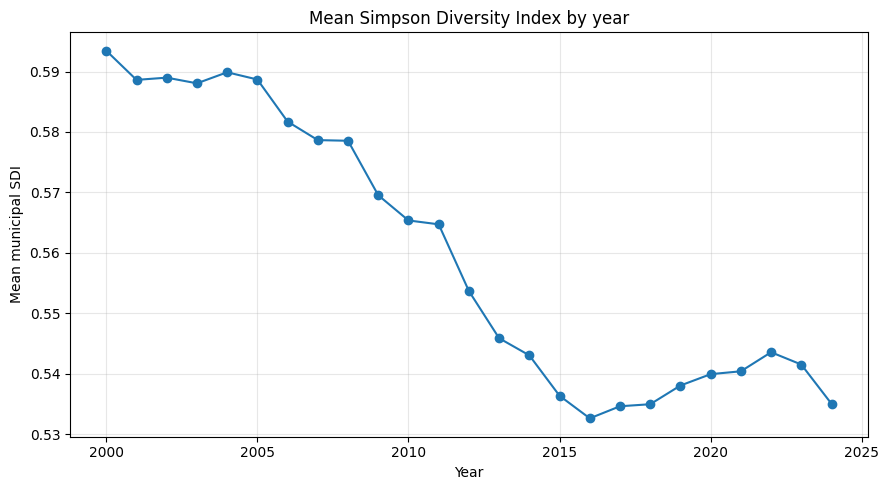

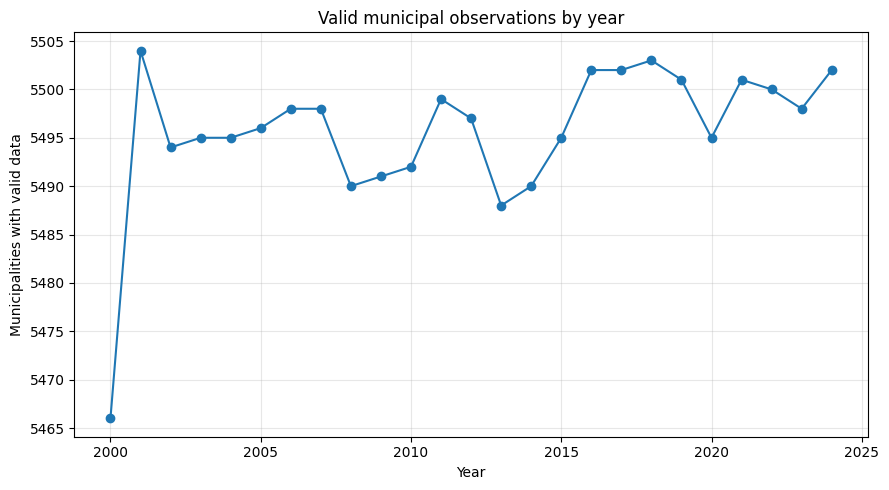

In [11]:
def save_current_figure(filename: str) -> None:
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / filename, dpi=200, bbox_inches="tight")
    plt.show()
    plt.close()


plt.figure(figsize=(9, 5))
plt.plot(annual_summary["year"], annual_summary["mean_sdi"], marker="o")
plt.xlabel("Year")
plt.ylabel("Mean municipal SDI")
plt.title("Mean Simpson Diversity Index by year")
plt.grid(alpha=0.3)
save_current_figure("01_annual_mean_sdi.png")

plt.figure(figsize=(9, 5))
plt.plot(annual_summary["year"], annual_summary["municipalities"], marker="o")
plt.xlabel("Year")
plt.ylabel("Municipalities with valid data")
plt.title("Valid municipal observations by year")
plt.grid(alpha=0.3)
save_current_figure("02_annual_municipality_count.png")


## 2. Model selection on the validation period

The search spaces are compact by design. Hyperparameters and the MLP architecture are selected only from the 2001–2013 training period and the 2014–2018 validation period. The 2019–2023 feature years remain untouched until the final evaluation.


In [12]:
RIDGE_ALPHAS = [1e-4, 1e-3, 1e-2, 0.1, 1.0, 10.0, 100.0]
RF_CANDIDATES = [
    {
        "n_estimators": 200,
        "max_depth": 14,
        "min_samples_leaf": 2,
        "max_features": "sqrt",
        "max_samples": 0.8,
    },
    {
        "n_estimators": 250,
        "max_depth": 18,
        "min_samples_leaf": 2,
        "max_features": 0.5,
        "max_samples": 0.8,
    },
    {
        "n_estimators": 250,
        "max_depth": None,
        "min_samples_leaf": 5,
        "max_features": "sqrt",
        "max_samples": 0.8,
    },
    {
        "n_estimators": 300,
        "max_depth": 20,
        "min_samples_leaf": 5,
        "max_features": 0.5,
        "max_samples": 0.8,
    },
]
XGB_CANDIDATES = [
    {"eta": 0.10, "max_depth": 4, "min_child_weight": 1, "subsample": 0.8, "colsample_bytree": 0.8, "lambda": 1.0},
    {"eta": 0.05, "max_depth": 4, "min_child_weight": 5, "subsample": 0.9, "colsample_bytree": 0.9, "lambda": 5.0},
    {"eta": 0.05, "max_depth": 6, "min_child_weight": 1, "subsample": 0.8, "colsample_bytree": 0.8, "lambda": 1.0},
    {"eta": 0.03, "max_depth": 6, "min_child_weight": 5, "subsample": 0.9, "colsample_bytree": 0.9, "lambda": 5.0},
]
MLP_CANDIDATES = {
    "basic": [
        {"hidden_units": [16, 8], "learning_rate": 1e-3, "l2": 1e-5, "dropout": 0.0, "batch_size": 512},
        {"hidden_units": [32, 16], "learning_rate": 5e-4, "l2": 1e-4, "dropout": 0.0, "batch_size": 512},
    ],
    "expanded": [
        {"hidden_units": [32, 16], "learning_rate": 1e-3, "l2": 1e-5, "dropout": 0.0, "batch_size": 512},
        {"hidden_units": [64, 32], "learning_rate": 1e-3, "l2": 1e-5, "dropout": 0.0, "batch_size": 512},
        {"hidden_units": [64, 32], "learning_rate": 3e-4, "l2": 1e-4, "dropout": 0.1, "batch_size": 512},
        {"hidden_units": [128, 64], "learning_rate": 3e-4, "l2": 1e-4, "dropout": 0.1, "batch_size": 512},
    ],
}
MAX_XGB_ROUNDS = 1200
MAX_MLP_EPOCHS = 250
EARLY_STOPPING_PATIENCE = 20


def build_mlp(
    input_dim: int,
    hidden_units: list[int],
    learning_rate: float,
    l2: float,
    dropout: float,
) -> tf.keras.Model:
    regularizer = tf.keras.regularizers.l2(l2) if l2 > 0 else None
    model = tf.keras.Sequential(name="sdi_mlp")
    model.add(tf.keras.layers.Input(shape=(input_dim,)))
    for units in hidden_units:
        model.add(
            tf.keras.layers.Dense(
                units,
                activation="relu",
                kernel_regularizer=regularizer,
            )
        )
        if dropout > 0:
            model.add(tf.keras.layers.Dropout(dropout))
    model.add(tf.keras.layers.Dense(1, activation="linear"))
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=learning_rate),
        loss="mse",
        metrics=[tf.keras.metrics.RootMeanSquaredError(name="rmse"), "mae"],
    )
    return model


def predict_booster(booster: xgb.Booster, matrix: xgb.DMatrix) -> np.ndarray:
    if getattr(booster, "best_iteration", None) is not None:
        return booster.predict(matrix, iteration_range=(0, booster.best_iteration + 1))
    return booster.predict(matrix)


In [13]:
search_rows = []
best_results = []
best_configuration: dict[str, dict] = {}
best_histories: dict[str, dict] = {}

for feature_set_name, feature_names in FEATURE_SETS.items():
    print(f"\nSelecting models for feature set: {feature_set_name}")
    X_train = train_frame[feature_names].to_numpy(dtype=np.float32)
    y_train = train_frame["target_sdi"].to_numpy(dtype=np.float32)
    X_validation = validation_frame[feature_names].to_numpy(dtype=np.float32)
    y_validation = validation_frame["target_sdi"].to_numpy(dtype=np.float32)

    best_configuration[feature_set_name] = {}
    best_histories[feature_set_name] = {}

    persistence_prediction = validation_frame["sdi"].to_numpy(dtype=np.float32)
    persistence_metrics = regression_metrics(y_validation, persistence_prediction)
    persistence_row = {
        "feature_set": feature_set_name,
        "model": "Persistence",
        "candidate_id": "persistence",
        **persistence_metrics,
    }
    search_rows.append(persistence_row)
    best_results.append(persistence_row)

    ridge_candidates = []
    for candidate_id, alpha in enumerate(RIDGE_ALPHAS, start=1):
        model = Pipeline([
            ("scaler", StandardScaler()),
            ("ridge", Ridge(alpha=alpha)),
        ])
        model.fit(X_train, y_train)
        metrics = regression_metrics(y_validation, model.predict(X_validation))
        row = {
            "feature_set": feature_set_name,
            "model": "Ridge",
            "candidate_id": f"ridge_{candidate_id}",
            "alpha": alpha,
            **metrics,
        }
        ridge_candidates.append(row)
        search_rows.append(row)
        del model
    ridge_best = min(ridge_candidates, key=lambda row: row["rmse"])
    best_results.append(ridge_best)
    best_configuration[feature_set_name]["ridge"] = {
        "params": {"alpha": ridge_best["alpha"]},
        "validation_metrics": {key: ridge_best[key] for key in ["mae", "rmse", "r2"]},
    }

    rf_best_row = None
    rf_best_params = None
    for candidate_id, params in enumerate(RF_CANDIDATES, start=1):
        model = RandomForestRegressor(**params, random_state=SEED, n_jobs=-1)
        model.fit(X_train, y_train)
        metrics = regression_metrics(y_validation, model.predict(X_validation))
        row = {
            "feature_set": feature_set_name,
            "model": "Random Forest",
            "candidate_id": f"rf_{candidate_id}",
            "params": json.dumps(params, sort_keys=True),
            **metrics,
        }
        search_rows.append(row)
        if rf_best_row is None or row["rmse"] < rf_best_row["rmse"]:
            rf_best_row = row
            rf_best_params = params.copy()
        del model
        gc.collect()
    best_results.append(rf_best_row)
    best_configuration[feature_set_name]["random_forest"] = {
        "params": rf_best_params,
        "validation_metrics": {key: rf_best_row[key] for key in ["mae", "rmse", "r2"]},
    }

    dtrain = xgb.DMatrix(X_train, label=y_train, feature_names=feature_names)
    dvalidation = xgb.DMatrix(X_validation, label=y_validation, feature_names=feature_names)
    xgb_best_row = None
    xgb_best_params = None
    xgb_best_history = None
    for candidate_id, candidate_params in enumerate(XGB_CANDIDATES, start=1):
        params = {
            "objective": "reg:squarederror",
            "eval_metric": "rmse",
            "tree_method": "hist",
            "seed": SEED,
            "nthread": -1,
            **candidate_params,
        }
        history = {}
        booster = xgb.train(
            params=params,
            dtrain=dtrain,
            num_boost_round=MAX_XGB_ROUNDS,
            evals=[(dtrain, "train"), (dvalidation, "validation")],
            evals_result=history,
            early_stopping_rounds=EARLY_STOPPING_PATIENCE,
            verbose_eval=False,
        )
        metrics = regression_metrics(y_validation, predict_booster(booster, dvalidation))
        row = {
            "feature_set": feature_set_name,
            "model": "XGBoost",
            "candidate_id": f"xgb_{candidate_id}",
            "params": json.dumps(candidate_params, sort_keys=True),
            "best_rounds": int(booster.best_iteration + 1),
            **metrics,
        }
        search_rows.append(row)
        if xgb_best_row is None or row["rmse"] < xgb_best_row["rmse"]:
            xgb_best_row = row
            xgb_best_params = candidate_params.copy()
            xgb_best_history = history
        del booster
        gc.collect()
    best_results.append(xgb_best_row)
    best_configuration[feature_set_name]["xgboost"] = {
        "params": xgb_best_params,
        "best_rounds": xgb_best_row["best_rounds"],
        "validation_metrics": {key: xgb_best_row[key] for key in ["mae", "rmse", "r2"]},
    }
    best_histories[feature_set_name]["xgboost"] = xgb_best_history
    del dtrain, dvalidation

    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train).astype(np.float32)
    X_validation_scaled = scaler.transform(X_validation).astype(np.float32)
    mlp_best_row = None
    mlp_best_params = None
    mlp_best_history = None

    for candidate_id, candidate_params in enumerate(MLP_CANDIDATES[feature_set_name], start=1):
        tf.keras.backend.clear_session()
        tf.keras.utils.set_random_seed(SEED + candidate_id)
        model = build_mlp(
            input_dim=X_train_scaled.shape[1],
            hidden_units=candidate_params["hidden_units"],
            learning_rate=candidate_params["learning_rate"],
            l2=candidate_params["l2"],
            dropout=candidate_params["dropout"],
        )
        early_stopping = tf.keras.callbacks.EarlyStopping(
            monitor="val_rmse",
            mode="min",
            patience=EARLY_STOPPING_PATIENCE,
            restore_best_weights=True,
        )
        history = model.fit(
            X_train_scaled,
            y_train,
            validation_data=(X_validation_scaled, y_validation),
            epochs=MAX_MLP_EPOCHS,
            batch_size=candidate_params["batch_size"],
            callbacks=[early_stopping],
            verbose=0,
            shuffle=True,
        )
        metrics = regression_metrics(
            y_validation,
            model.predict(X_validation_scaled, verbose=0).ravel(),
        )
        row = {
            "feature_set": feature_set_name,
            "model": "MLP",
            "candidate_id": f"mlp_{candidate_id}",
            "params": json.dumps(candidate_params, sort_keys=True),
            "best_epoch": int(np.argmin(history.history["val_rmse"]) + 1),
            **metrics,
        }
        search_rows.append(row)
        if mlp_best_row is None or row["rmse"] < mlp_best_row["rmse"]:
            mlp_best_row = row
            mlp_best_params = candidate_params.copy()
            mlp_best_history = {key: list(values) for key, values in history.history.items()}
        del model, history
        tf.keras.backend.clear_session()
        gc.collect()

    best_results.append(mlp_best_row)
    best_configuration[feature_set_name]["mlp"] = {
        "params": mlp_best_params,
        "best_epoch": mlp_best_row["best_epoch"],
        "validation_metrics": {key: mlp_best_row[key] for key in ["mae", "rmse", "r2"]},
    }
    best_histories[feature_set_name]["mlp"] = mlp_best_history

    del X_train, y_train, X_validation, y_validation
    del X_train_scaled, X_validation_scaled, scaler
    gc.collect()

search_results = pd.DataFrame(search_rows)
validation_best = pd.DataFrame(best_results)
display(validation_best.sort_values(["feature_set", "rmse"]))



Selecting models for feature set: basic

Selecting models for feature set: expanded


,feature_set,model,candidate_id,mae,rmse,r2,alpha,params,best_rounds,best_epoch
3,basic,XGBoost,xgb_3,0.051239,0.083877,0.814634,NaN,"{""colsample_bytree"": 0.8, ""eta"": 0.05, ""lambda...",70.0,NaN
4,basic,MLP,mlp_2,0.050377,0.084045,0.813891,NaN,"{""batch_size"": 512, ""dropout"": 0.0, ""hidden_un...",NaN,10.0
1,basic,Ridge,ridge_7,0.050060,0.084234,0.813050,100.0,NaN,NaN,NaN
2,basic,Random Forest,rf_1,0.051857,0.085567,0.807090,NaN,"{""max_depth"": 14, ""max_features"": ""sqrt"", ""max...",NaN,NaN
0,basic,Persistence,persistence,0.048884,0.086397,0.803330,NaN,NaN,NaN,NaN
7,expanded,Random Forest,rf_3,0.050661,0.081875,0.823375,NaN,"{""max_depth"": null, ""max_features"": ""sqrt"", ""m...",NaN,NaN
8,expanded,XGBoost,xgb_4,0.050370,0.081933,0.823126,NaN,"{""colsample_bytree"": 0.9, ""eta"": 0.03, ""lambda...",139.0,NaN
9,expanded,MLP,mlp_3,0.051930,0.082599,0.820240,NaN,"{""batch_size"": 512, ""dropout"": 0.1, ""hidden_un...",NaN,107.0
6,expanded,Ridge,ridge_7,0.050908,0.082763,0.819524,100.0,NaN,NaN,NaN
5,expanded,Persistence,persistence,0.048884,0.086397,0.803330,NaN,NaN,NaN,NaN


## 3. Training and validation curves

Curves are generated for every implemented approach using the primary expanded feature set.

- Ridge and Random Forest use chronological learning curves based on expanding training windows.
- XGBoost uses RMSE by boosting round.
- MLP uses RMSE by epoch.
- Persistence has no fitted parameters; its reference curve reports the errors observed in the same expanding temporal windows.


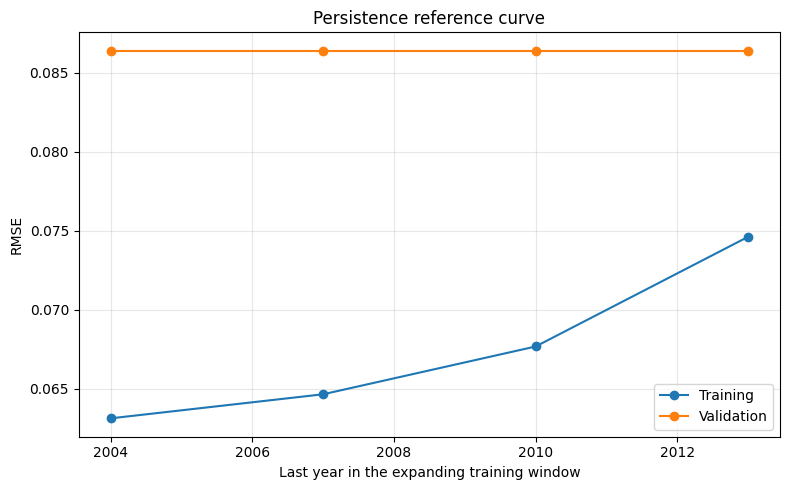

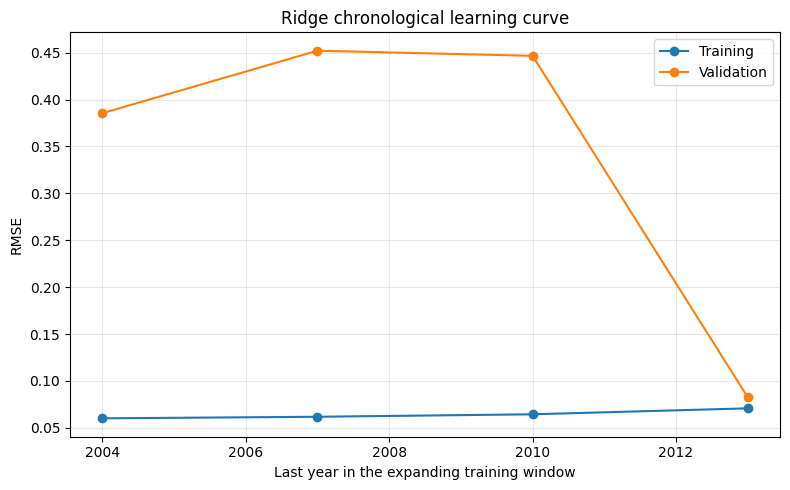

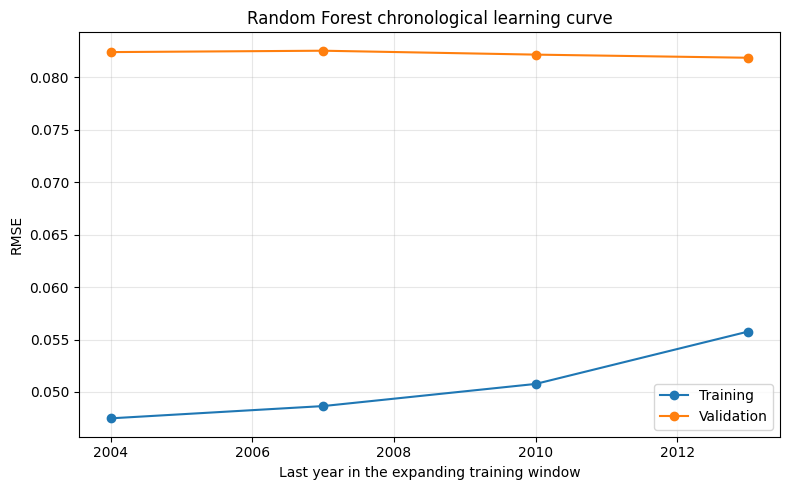

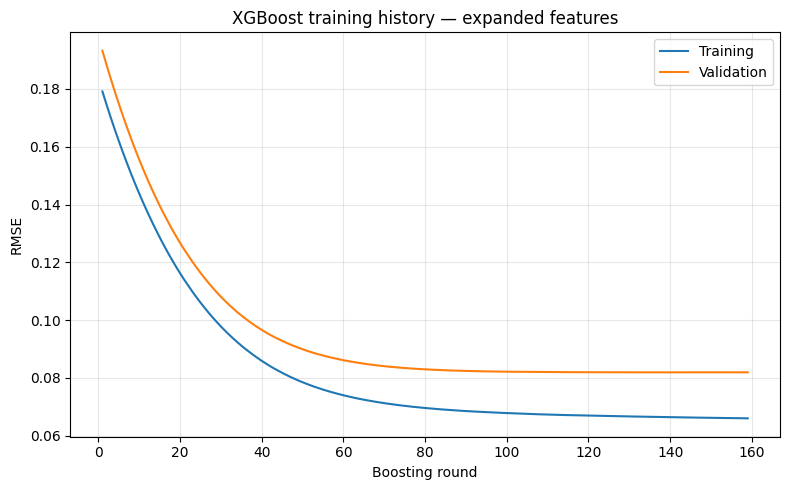

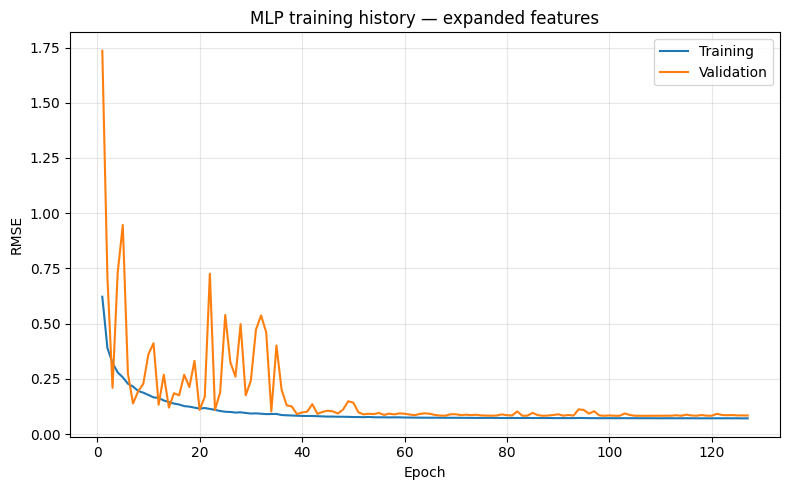

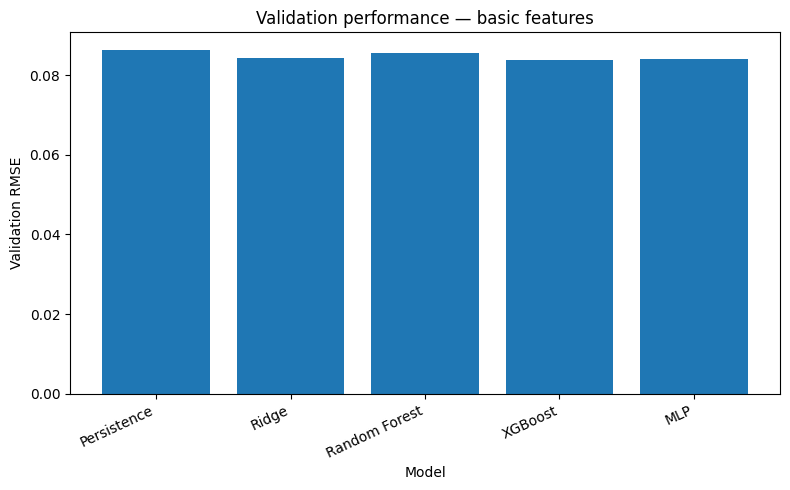

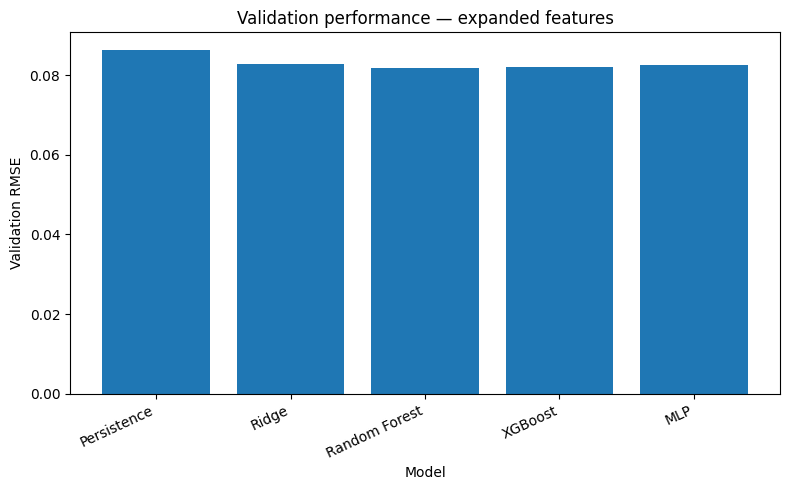

13674

In [14]:
primary_features = FEATURE_SETS["expanded"]
X_validation_primary = validation_frame[primary_features].to_numpy(dtype=np.float32)
y_validation_primary = validation_frame["target_sdi"].to_numpy(dtype=np.float32)
validation_persistence = validation_frame["sdi"].to_numpy(dtype=np.float32)

learning_curve_rows = []
for end_year in [2004, 2007, 2010, 2013]:
    subset = train_frame.loc[train_frame["year"] <= end_year]
    X_subset = subset[primary_features].to_numpy(dtype=np.float32)
    y_subset = subset["target_sdi"].to_numpy(dtype=np.float32)

    # Persistence does not fit parameters; these are reference errors for each time window.
    learning_curve_rows.extend([
        {
            "model": "Persistence",
            "training_end_year": end_year,
            "sample": "Training",
            "rmse": regression_metrics(
                y_subset,
                subset["sdi"].to_numpy(dtype=np.float32),
            )["rmse"],
        },
        {
            "model": "Persistence",
            "training_end_year": end_year,
            "sample": "Validation",
            "rmse": regression_metrics(
                y_validation_primary,
                validation_persistence,
            )["rmse"],
        },
    ])

    ridge_model = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=best_configuration["expanded"]["ridge"]["params"]["alpha"])),
    ])
    ridge_model.fit(X_subset, y_subset)
    learning_curve_rows.extend([
        {
            "model": "Ridge",
            "training_end_year": end_year,
            "sample": "Training",
            "rmse": regression_metrics(y_subset, ridge_model.predict(X_subset))["rmse"],
        },
        {
            "model": "Ridge",
            "training_end_year": end_year,
            "sample": "Validation",
            "rmse": regression_metrics(
                y_validation_primary,
                ridge_model.predict(X_validation_primary),
            )["rmse"],
        },
    ])

    rf_model = RandomForestRegressor(
        **best_configuration["expanded"]["random_forest"]["params"],
        random_state=SEED,
        n_jobs=-1,
    )
    rf_model.fit(X_subset, y_subset)
    learning_curve_rows.extend([
        {
            "model": "Random Forest",
            "training_end_year": end_year,
            "sample": "Training",
            "rmse": regression_metrics(y_subset, rf_model.predict(X_subset))["rmse"],
        },
        {
            "model": "Random Forest",
            "training_end_year": end_year,
            "sample": "Validation",
            "rmse": regression_metrics(
                y_validation_primary,
                rf_model.predict(X_validation_primary),
            )["rmse"],
        },
    ])
    del ridge_model, rf_model, X_subset, y_subset
    gc.collect()

learning_curves = pd.DataFrame(learning_curve_rows)

curve_file_numbers = {
    "Persistence": 3,
    "Ridge": 4,
    "Random Forest": 5,
}
for model_name in ["Persistence", "Ridge", "Random Forest"]:
    plot_data = learning_curves.loc[learning_curves["model"] == model_name]
    plt.figure(figsize=(8, 5))
    for sample_name, sample_data in plot_data.groupby("sample"):
        plt.plot(
            sample_data["training_end_year"],
            sample_data["rmse"],
            marker="o",
            label=sample_name,
        )
    plt.xlabel("Last year in the expanding training window")
    plt.ylabel("RMSE")
    title_suffix = "reference curve" if model_name == "Persistence" else "chronological learning curve"
    plt.title(f"{model_name} {title_suffix}")
    plt.legend()
    plt.grid(alpha=0.3)
    save_current_figure(
        f"{curve_file_numbers[model_name]:02d}_{model_name.lower().replace(' ', '_')}_learning_curve.png"
    )

xgb_history = best_histories["expanded"]["xgboost"]
xgb_history_table = pd.DataFrame({
    "boosting_round": np.arange(1, len(xgb_history["train"]["rmse"]) + 1),
    "training_rmse": xgb_history["train"]["rmse"],
    "validation_rmse": xgb_history["validation"]["rmse"],
})
plt.figure(figsize=(8, 5))
plt.plot(xgb_history_table["boosting_round"], xgb_history_table["training_rmse"], label="Training")
plt.plot(xgb_history_table["boosting_round"], xgb_history_table["validation_rmse"], label="Validation")
plt.xlabel("Boosting round")
plt.ylabel("RMSE")
plt.title("XGBoost training history — expanded features")
plt.legend()
plt.grid(alpha=0.3)
save_current_figure("06_xgboost_training_history.png")

mlp_history = best_histories["expanded"]["mlp"]
mlp_history_table = pd.DataFrame({
    "epoch": np.arange(1, len(mlp_history["rmse"]) + 1),
    "training_rmse": mlp_history["rmse"],
    "validation_rmse": mlp_history["val_rmse"],
})
plt.figure(figsize=(8, 5))
plt.plot(mlp_history_table["epoch"], mlp_history_table["training_rmse"], label="Training")
plt.plot(mlp_history_table["epoch"], mlp_history_table["validation_rmse"], label="Validation")
plt.xlabel("Epoch")
plt.ylabel("RMSE")
plt.title("MLP training history — expanded features")
plt.legend()
plt.grid(alpha=0.3)
save_current_figure("07_mlp_training_history.png")

model_order = ["Persistence", "Ridge", "Random Forest", "XGBoost", "MLP"]
for figure_number, feature_set_name in enumerate(FEATURE_SETS, start=8):
    subset = validation_best.loc[validation_best["feature_set"] == feature_set_name].copy()
    subset["model"] = pd.Categorical(subset["model"], categories=model_order, ordered=True)
    subset = subset.sort_values("model")
    plt.figure(figsize=(8, 5))
    plt.bar(subset["model"].astype(str), subset["rmse"])
    plt.xlabel("Model")
    plt.ylabel("Validation RMSE")
    plt.title(f"Validation performance — {feature_set_name} features")
    plt.xticks(rotation=25, ha="right")
    save_current_figure(f"{figure_number:02d}_validation_rmse_{feature_set_name}.png")

del X_validation_primary, y_validation_primary, validation_persistence
gc.collect()


## 4. Final retraining and test evaluation

Each selected model is retrained on the combined 2001–2018 development period and evaluated once on the reserved 2020–2024 targets. Models are processed sequentially and removed from memory after their predictions and interpretation measures are calculated.


In [15]:
def permutation_importance_rmse(
    predict_function,
    X: np.ndarray,
    y: np.ndarray,
    feature_names: list[str],
    sample_size: int,
    repeats: int,
    seed: int,
    display_name_function,
) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    if len(X) > sample_size:
        indices = rng.choice(len(X), size=sample_size, replace=False)
        X_work = X[indices].copy()
        y_work = y[indices].copy()
    else:
        X_work = X.copy()
        y_work = y.copy()

    baseline_rmse = regression_metrics(y_work, predict_function(X_work))["rmse"]
    rows = []
    for column_index, feature in enumerate(feature_names):
        original = X_work[:, column_index].copy()
        increases = []
        for _ in range(repeats):
            X_work[:, column_index] = rng.permutation(original)
            shuffled_rmse = regression_metrics(y_work, predict_function(X_work))["rmse"]
            increases.append(shuffled_rmse - baseline_rmse)
        X_work[:, column_index] = original
        rows.append({
            "feature": feature,
            "display_name": display_name_function(feature),
            "mean_rmse_increase": float(np.mean(increases)),
            "std_rmse_increase": float(np.std(increases, ddof=1)) if repeats > 1 else 0.0,
        })

    result = pd.DataFrame(rows).sort_values("mean_rmse_increase", ascending=False)
    positive_total = result["mean_rmse_increase"].clip(lower=0).sum()
    result["relative_importance_pct"] = np.where(
        positive_total > 0,
        100 * result["mean_rmse_increase"].clip(lower=0) / positive_total,
        0.0,
    )
    return result


share_display_names = dict(
    zip(
        crop_dictionary["share_feature"],
        crop_dictionary["english_product"].map(lambda value: f"Share: {value}"),
    )
)
summary_display_names = {
    "sdi": "Current SDI",
    "number_of_crops": "Number of crops",
    "total_registered_area": "Total registered crop area",
    "cr1": "CR1",
    "cr4": "CR4",
    "sdi_lag1": "Previous-year SDI",
    "sdi_change": "Annual SDI change",
    "number_of_crops_change": "Annual change in crop count",
}


def display_name(feature: str) -> str:
    return share_display_names.get(feature, summary_display_names.get(feature, feature))


development_frame = pd.concat([train_frame, validation_frame], ignore_index=True)
del train_frame, validation_frame
gc.collect()

prediction_rows = []
metric_rows = []
interpretation_tables: dict[str, pd.DataFrame] = {}

for feature_set_name, feature_names in FEATURE_SETS.items():
    print(f"\nFinal training for feature set: {feature_set_name}")
    X_development = development_frame[feature_names].to_numpy(dtype=np.float32)
    y_development = development_frame["target_sdi"].to_numpy(dtype=np.float32)
    X_test = test_frame[feature_names].to_numpy(dtype=np.float32)
    y_test = test_frame["target_sdi"].to_numpy(dtype=np.float32)
    predictions: dict[str, np.ndarray] = {
        "Persistence": test_frame["sdi"].to_numpy(dtype=np.float32)
    }

    ridge_config = best_configuration[feature_set_name]["ridge"]
    ridge_model = Pipeline([
        ("scaler", StandardScaler()),
        ("ridge", Ridge(alpha=ridge_config["params"]["alpha"])),
    ])
    ridge_model.fit(X_development, y_development)
    predictions["Ridge"] = ridge_model.predict(X_test)
    if feature_set_name == "expanded":
        ridge_coefficients = pd.DataFrame({
            "feature": feature_names,
            "display_name": [display_name(feature) for feature in feature_names],
            "coefficient": ridge_model.named_steps["ridge"].coef_,
        })
        ridge_coefficients["absolute_importance"] = ridge_coefficients["coefficient"].abs()
        ridge_coefficients["relative_importance_pct"] = (
            100
            * ridge_coefficients["absolute_importance"]
            / ridge_coefficients["absolute_importance"].sum()
        )
        interpretation_tables["ridge_coefficients"] = ridge_coefficients.sort_values(
            "absolute_importance", ascending=False
        )
    del ridge_model
    gc.collect()

    rf_config = best_configuration[feature_set_name]["random_forest"]
    rf_model = RandomForestRegressor(
        **rf_config["params"],
        random_state=SEED,
        n_jobs=-1,
    )
    rf_model.fit(X_development, y_development)
    predictions["Random Forest"] = rf_model.predict(X_test)
    if feature_set_name == "expanded":
        interpretation_tables["random_forest_permutation"] = permutation_importance_rmse(
            predict_function=rf_model.predict,
            X=X_test,
            y=y_test,
            feature_names=feature_names,
            sample_size=PERMUTATION_SAMPLE_SIZE,
            repeats=PERMUTATION_REPEATS,
            seed=SEED,
            display_name_function=display_name,
        )
    del rf_model
    gc.collect()

    xgb_config = best_configuration[feature_set_name]["xgboost"]
    xgb_params = {
        "objective": "reg:squarederror",
        "eval_metric": "rmse",
        "tree_method": "hist",
        "seed": SEED,
        "nthread": -1,
        **xgb_config["params"],
    }
    ddevelopment = xgb.DMatrix(X_development, label=y_development, feature_names=feature_names)
    xgb_model = xgb.train(
        params=xgb_params,
        dtrain=ddevelopment,
        num_boost_round=int(xgb_config["best_rounds"]),
        verbose_eval=False,
    )
    predictions["XGBoost"] = xgb_model.inplace_predict(X_test)
    if feature_set_name == "expanded":
        interpretation_tables["xgboost_permutation"] = permutation_importance_rmse(
            predict_function=xgb_model.inplace_predict,
            X=X_test,
            y=y_test,
            feature_names=feature_names,
            sample_size=PERMUTATION_SAMPLE_SIZE,
            repeats=PERMUTATION_REPEATS,
            seed=SEED,
            display_name_function=display_name,
        )
    del xgb_model, ddevelopment
    gc.collect()

    mlp_config = best_configuration[feature_set_name]["mlp"]
    mlp_params = mlp_config["params"]
    scaler = StandardScaler()
    X_development_scaled = scaler.fit_transform(X_development).astype(np.float32)
    X_test_scaled = scaler.transform(X_test).astype(np.float32)

    tf.keras.backend.clear_session()
    tf.keras.utils.set_random_seed(SEED)
    mlp_model = build_mlp(
        input_dim=X_development_scaled.shape[1],
        hidden_units=mlp_params["hidden_units"],
        learning_rate=mlp_params["learning_rate"],
        l2=mlp_params["l2"],
        dropout=mlp_params["dropout"],
    )
    mlp_model.fit(
        X_development_scaled,
        y_development,
        epochs=int(mlp_config["best_epoch"]),
        batch_size=int(mlp_params["batch_size"]),
        verbose=0,
        shuffle=True,
    )
    predictions["MLP"] = mlp_model.predict(X_test_scaled, verbose=0).ravel()

    if feature_set_name == "expanded":
        dense_layers = [
            layer for layer in mlp_model.layers
            if isinstance(layer, tf.keras.layers.Dense)
        ]
        if len(dense_layers) != 3:
            raise ValueError(
                "Olden importance requires two hidden Dense layers and one output Dense layer."
            )
        combined_weights = dense_layers[0].get_weights()[0]
        for layer in dense_layers[1:]:
            combined_weights = combined_weights @ layer.get_weights()[0]
        olden_values = combined_weights.reshape(-1)
        mlp_olden = pd.DataFrame({
            "feature": feature_names,
            "display_name": [display_name(feature) for feature in feature_names],
            "olden_contribution": olden_values,
        })
        mlp_olden["absolute_importance"] = mlp_olden["olden_contribution"].abs()
        mlp_olden["relative_importance_pct"] = (
            100
            * mlp_olden["absolute_importance"]
            / mlp_olden["absolute_importance"].sum()
        )
        interpretation_tables["mlp_olden"] = mlp_olden.sort_values(
            "absolute_importance", ascending=False
        )

    del mlp_model, scaler, X_development_scaled, X_test_scaled
    tf.keras.backend.clear_session()
    gc.collect()

    persistence_rmse = regression_metrics(y_test, predictions["Persistence"])["rmse"]
    for model_name, prediction in predictions.items():
        metrics = regression_metrics(y_test, prediction)
        metric_rows.append({
            "feature_set": feature_set_name,
            "model": model_name,
            **metrics,
            "rmse_improvement_over_persistence_pct": (
                100.0 * (persistence_rmse - metrics["rmse"]) / persistence_rmse
            ),
            "predictions_below_zero": int(np.sum(prediction < 0)),
            "predictions_above_one": int(np.sum(prediction > 1)),
        })

        model_predictions = test_frame[[
            "municipality_label",
            "municipality_name",
            "state_code",
            "year",
            "target_year",
            "target_sdi",
        ]].copy()
        model_predictions["feature_set"] = feature_set_name
        model_predictions["model"] = model_name
        model_predictions["predicted_sdi"] = prediction
        model_predictions["residual"] = model_predictions["target_sdi"] - prediction
        prediction_rows.append(model_predictions)

    del X_development, y_development, X_test, y_test, predictions
    gc.collect()

metrics_table = pd.DataFrame(metric_rows)
predictions_long = pd.concat(prediction_rows, ignore_index=True)
display(metrics_table.sort_values(["feature_set", "rmse"]))



Final training for feature set: basic

Final training for feature set: expanded


,feature_set,model,mae,rmse,r2,rmse_improvement_over_persistence_pct,predictions_below_zero,predictions_above_one
1,basic,Ridge,0.036910,0.063158,0.887280,1.247349,0,0
4,basic,MLP,0.037669,0.063505,0.886038,0.704782,0,0
3,basic,XGBoost,0.038619,0.063823,0.884895,0.207765,0,0
0,basic,Persistence,0.033494,0.063956,0.884415,0.000000,0,0
2,basic,Random Forest,0.038300,0.064790,0.881379,-1.304876,0,0
8,expanded,XGBoost,0.037521,0.062225,0.890588,2.706937,0,0
7,expanded,Random Forest,0.037765,0.062413,0.889924,2.412074,0,0
6,expanded,Ridge,0.037516,0.062629,0.889162,2.075230,0,0
5,expanded,Persistence,0.033494,0.063956,0.884415,0.000000,0,0
9,expanded,MLP,0.041218,0.064366,0.882927,-0.641645,0,0


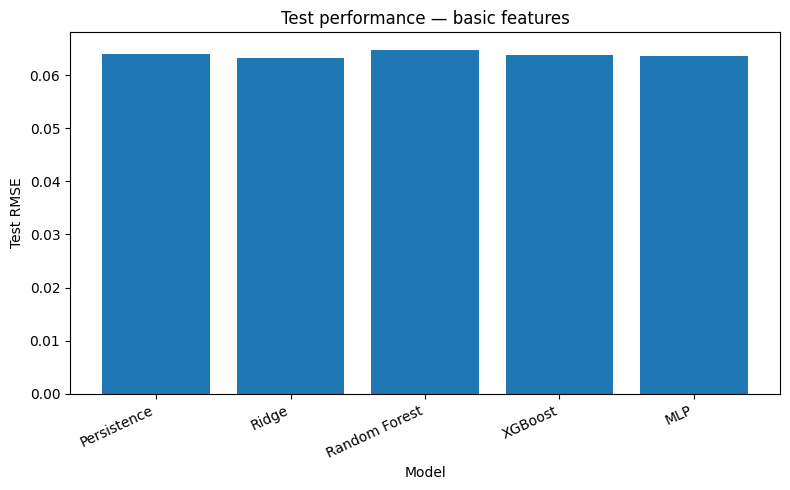

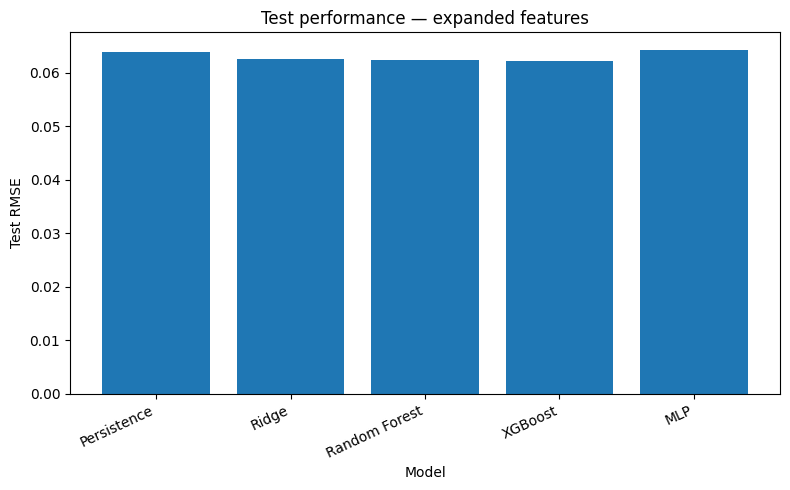

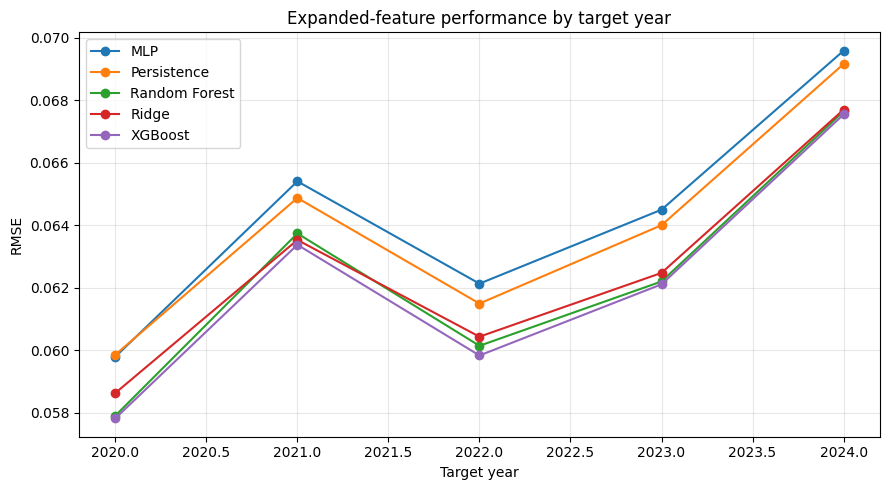

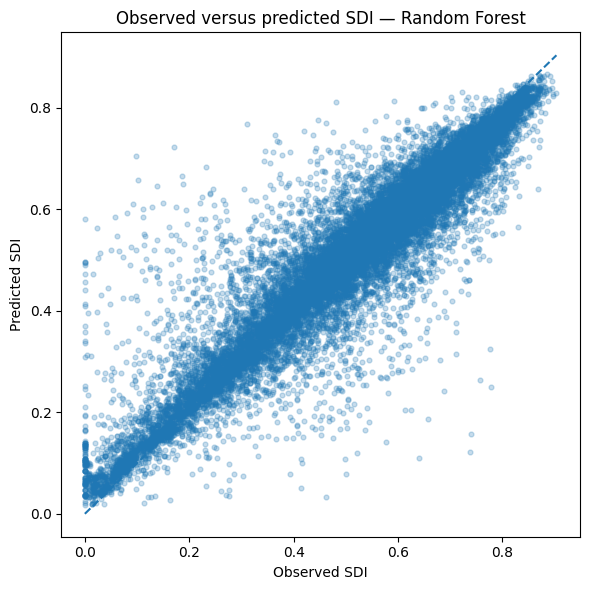

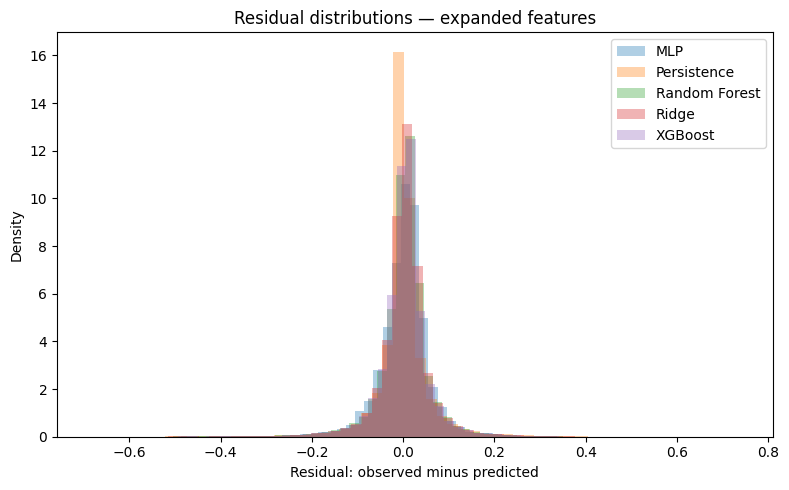

In [16]:
per_year_rows = []
for (feature_set_name, model_name, target_year), group in predictions_long.groupby(
    ["feature_set", "model", "target_year"]
):
    metrics = regression_metrics(group["target_sdi"], group["predicted_sdi"])
    per_year_rows.append({
        "feature_set": feature_set_name,
        "model": model_name,
        "target_year": int(target_year),
        "observations": len(group),
        **metrics,
    })
per_year_metrics = pd.DataFrame(per_year_rows)

for figure_number, feature_set_name in enumerate(FEATURE_SETS, start=10):
    subset = metrics_table.loc[metrics_table["feature_set"] == feature_set_name].copy()
    subset["model"] = pd.Categorical(subset["model"], categories=model_order, ordered=True)
    subset = subset.sort_values("model")
    plt.figure(figsize=(8, 5))
    plt.bar(subset["model"].astype(str), subset["rmse"])
    plt.xlabel("Model")
    plt.ylabel("Test RMSE")
    plt.title(f"Test performance — {feature_set_name} features")
    plt.xticks(rotation=25, ha="right")
    save_current_figure(f"{figure_number:02d}_test_rmse_{feature_set_name}.png")

expanded_yearly = per_year_metrics.loc[per_year_metrics["feature_set"] == "expanded"]
plt.figure(figsize=(9, 5))
for model_name, group in expanded_yearly.groupby("model"):
    plt.plot(group["target_year"], group["rmse"], marker="o", label=model_name)
plt.xlabel("Target year")
plt.ylabel("RMSE")
plt.title("Expanded-feature performance by target year")
plt.legend()
plt.grid(alpha=0.3)
save_current_figure("12_expanded_rmse_by_target_year.png")

selected_model_name = (
    validation_best.loc[validation_best["feature_set"] == "expanded"]
    .sort_values("rmse")
    .iloc[0]["model"]
)
selected_predictions = predictions_long.loc[
    (predictions_long["feature_set"] == "expanded")
    & (predictions_long["model"] == selected_model_name)
]

plt.figure(figsize=(6, 6))
plt.scatter(
    selected_predictions["target_sdi"],
    selected_predictions["predicted_sdi"],
    alpha=0.25,
    s=12,
)
limits = [
    min(selected_predictions["target_sdi"].min(), selected_predictions["predicted_sdi"].min()),
    max(selected_predictions["target_sdi"].max(), selected_predictions["predicted_sdi"].max()),
]
plt.plot(limits, limits, linestyle="--")
plt.xlabel("Observed SDI")
plt.ylabel("Predicted SDI")
plt.title(f"Observed versus predicted SDI — {selected_model_name}")
save_current_figure("13_selected_model_observed_vs_predicted.png")

plt.figure(figsize=(8, 5))
for model_name, group in predictions_long.loc[
    predictions_long["feature_set"] == "expanded"
].groupby("model"):
    plt.hist(group["residual"], bins=60, alpha=0.35, density=True, label=model_name)
plt.xlabel("Residual: observed minus predicted")
plt.ylabel("Density")
plt.title("Residual distributions — expanded features")
plt.legend()
save_current_figure("14_expanded_residual_distributions.png")


## 5. Model interpretation

Ridge coefficients use standardized inputs. Random Forest and XGBoost use permutation importance measured by the increase in RMSE after shuffling one feature. MLP importance uses the Olden connection-weight product across the two hidden layers.


,feature,display_name,coefficient,absolute_importance,relative_importance_pct
62,sdi,Current SDI,0.088301,0.088301,36.990154
67,sdi_lag1,Previous-year SDI,0.081256,0.081256,34.038971
68,sdi_change,Annual SDI change,0.018436,0.018436,7.722980
15,share_sugarcane,Share: Sugarcane,-0.004985,0.004985,2.088437
46,share_corn,Share: Corn,0.004707,0.004707,1.971915
66,cr4,CR4,-0.004144,0.004144,1.736167
54,share_soybean,Share: Soybean,-0.002570,0.002570,1.076755
65,cr1,CR1,0.002333,0.002333,0.977427
40,share_cassava,Share: Cassava,0.002318,0.002318,0.971198
63,number_of_crops,Number of crops,0.002093,0.002093,0.876575


,feature,display_name,mean_rmse_increase,std_rmse_increase,relative_importance_pct
62,sdi,Current SDI,0.043956,0.000396,42.593551
65,cr1,CR1,0.026380,0.000313,25.561824
67,sdi_lag1,Previous-year SDI,0.018753,0.000286,18.171709
66,cr4,CR4,0.003671,0.000198,3.557545
15,share_sugarcane,Share: Sugarcane,0.002855,0.000450,2.766615
54,share_soybean,Share: Soybean,0.001840,0.000178,1.782768
46,share_corn,Share: Corn,0.001752,0.000076,1.697703
27,share_beans,Share: Beans,0.001031,0.000080,0.998932
40,share_cassava,Share: Cassava,0.000445,0.000087,0.430896
14,share_coffee_beans_total,"Share: Coffee beans, total",0.000441,0.000020,0.426899


,feature,display_name,mean_rmse_increase,std_rmse_increase,relative_importance_pct
62,sdi,Current SDI,0.125407,0.000790,75.256780
67,sdi_lag1,Previous-year SDI,0.024766,0.000220,14.861960
65,cr1,CR1,0.011519,0.000271,6.912764
27,share_beans,Share: Beans,0.001633,0.000055,0.979734
64,total_registered_area,Total registered crop area,0.000866,0.000134,0.519731
54,share_soybean,Share: Soybean,0.000827,0.000124,0.496174
66,cr4,CR4,0.000402,0.000012,0.241266
57,share_tomato,Share: Tomato,0.000287,0.000211,0.172053
46,share_corn,Share: Corn,0.000170,0.000064,0.101822
63,number_of_crops,Number of crops,0.000139,0.000054,0.083130


,feature,display_name,olden_contribution,absolute_importance,relative_importance_pct
62,sdi,Current SDI,0.282471,0.282471,22.830746
67,sdi_lag1,Previous-year SDI,0.266241,0.266241,21.519030
65,cr1,CR1,-0.060218,0.060218,4.867115
66,cr4,CR4,-0.041940,0.041940,3.389800
15,share_sugarcane,Share: Sugarcane,-0.037668,0.037668,3.044511
54,share_soybean,Share: Soybean,-0.037278,0.037278,3.013039
30,share_guava,Share: Guava,0.035323,0.035323,2.854981
68,sdi_change,Annual SDI change,0.033314,0.033314,2.692616
27,share_beans,Share: Beans,0.022933,0.022933,1.853558
17,share_cashew_nuts,Share: Cashew nuts,0.022430,0.022430,1.812921


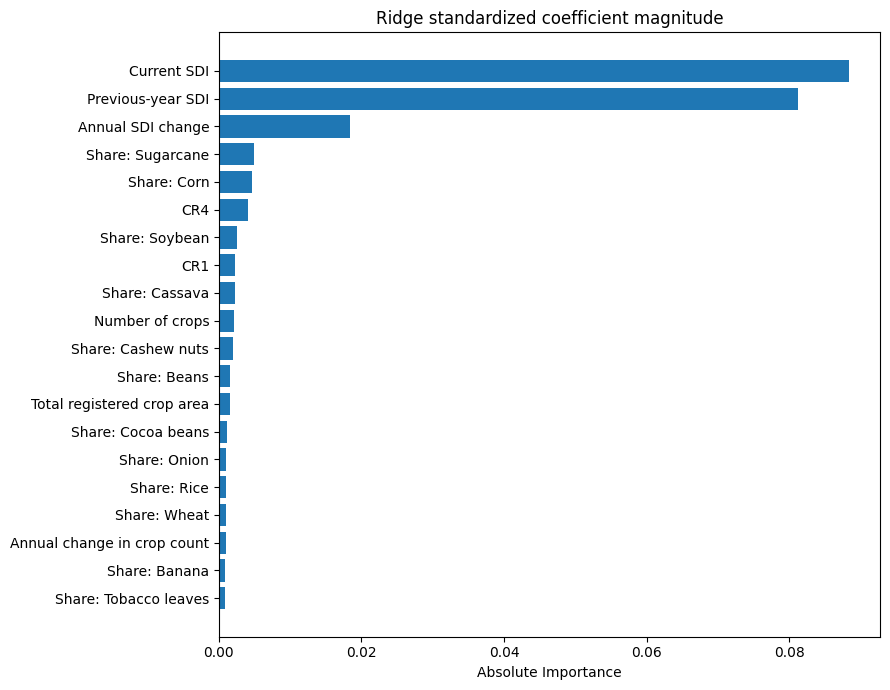

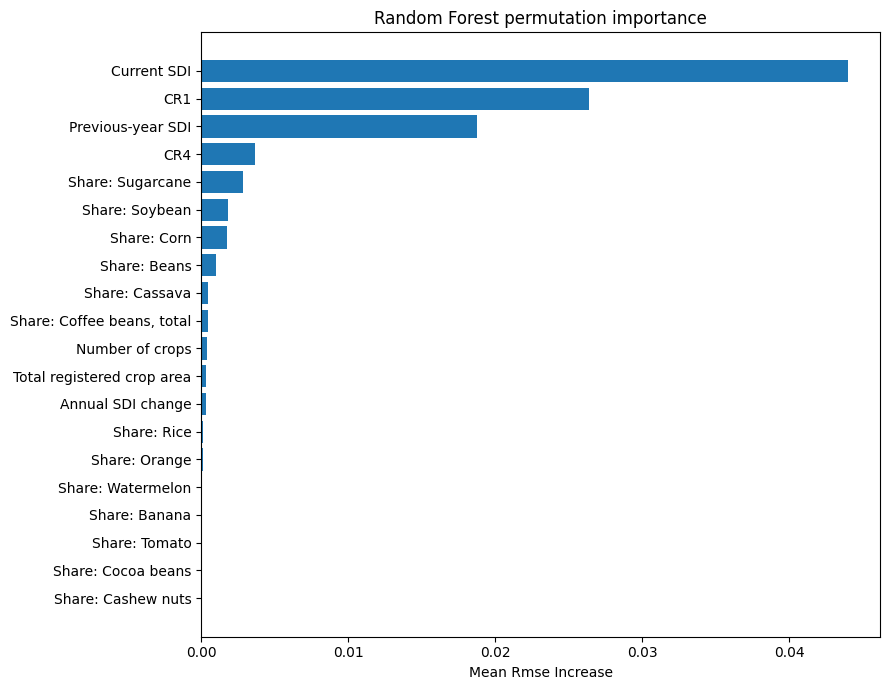

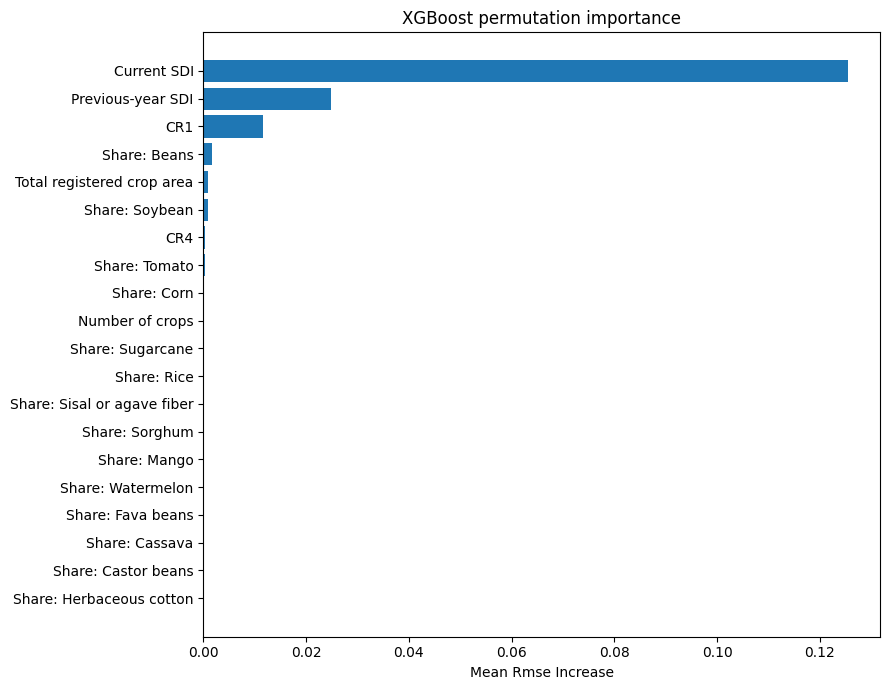

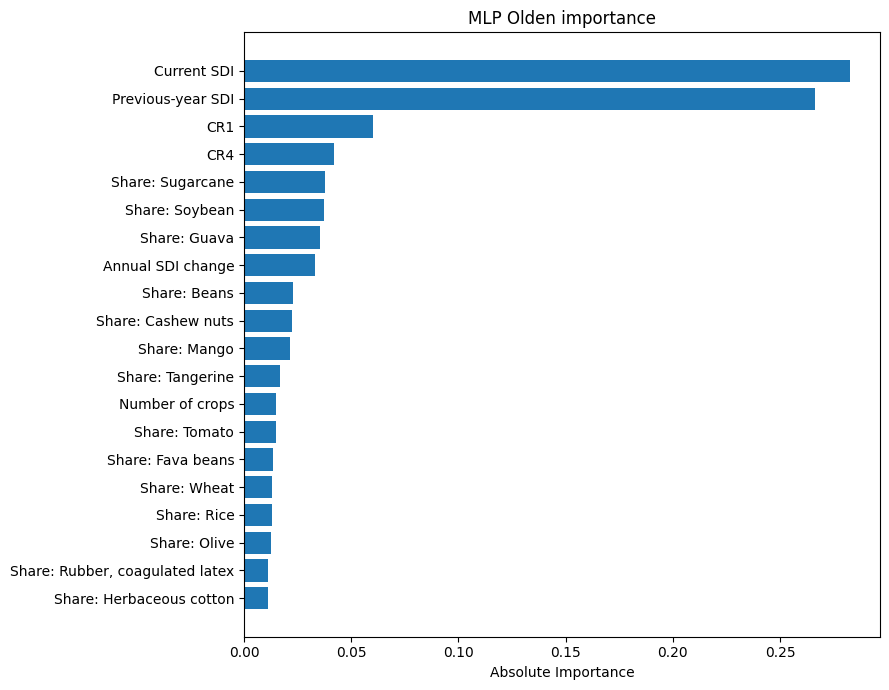

In [17]:
def plot_top_importance(
    frame: pd.DataFrame,
    value_column: str,
    title: str,
    filename: str,
) -> None:
    top = frame.head(20).sort_values(value_column)
    plt.figure(figsize=(9, 7))
    plt.barh(top["display_name"], top[value_column])
    plt.xlabel(value_column.replace("_", " ").title())
    plt.title(title)
    save_current_figure(filename)


ridge_coefficients = interpretation_tables["ridge_coefficients"]
rf_importance = interpretation_tables["random_forest_permutation"]
xgb_importance = interpretation_tables["xgboost_permutation"]
mlp_olden = interpretation_tables["mlp_olden"]

display(ridge_coefficients.head(15))
display(rf_importance.head(15))
display(xgb_importance.head(15))
display(mlp_olden.head(15))

plot_top_importance(
    ridge_coefficients,
    "absolute_importance",
    "Ridge standardized coefficient magnitude",
    "15_ridge_importance.png",
)
plot_top_importance(
    rf_importance,
    "mean_rmse_increase",
    "Random Forest permutation importance",
    "16_random_forest_permutation_importance.png",
)
plot_top_importance(
    xgb_importance,
    "mean_rmse_increase",
    "XGBoost permutation importance",
    "17_xgboost_permutation_importance.png",
)
plot_top_importance(
    mlp_olden,
    "absolute_importance",
    "MLP Olden importance",
    "18_mlp_olden_importance.png",
)


## 6. Export final results

All intermediate objects remain in the temporary Colab runtime. The source folder receives only the compressed final-results archive.


In [18]:
TABLES = {
    "annual_sdi_summary.csv": annual_summary,
    "source_data_audit.csv": source_audit,
    "crop_dictionary.csv": crop_dictionary,
    "crop_coverage_audit.csv": crop_audit,
    "crop_coverage_by_year.csv": coverage_by_year,
    "coffee_consistency_check.csv": coffee_summary,
    "transition_counts.csv": transition_summary,
    "validation_search_results.csv": search_results,
    "validation_best_results.csv": validation_best,
    "chronological_learning_curves.csv": learning_curves,
    "xgboost_training_history.csv": xgb_history_table,
    "mlp_training_history.csv": mlp_history_table,
    "test_metrics.csv": metrics_table,
    "test_metrics_by_year.csv": per_year_metrics,
    "ridge_coefficients_expanded.csv": ridge_coefficients,
    "random_forest_permutation_importance.csv": rf_importance,
    "xgboost_permutation_importance.csv": xgb_importance,
    "mlp_olden_importance.csv": mlp_olden,
}

for filename, frame in TABLES.items():
    frame.to_csv(TABLE_DIR / filename, index=False)

predictions_long.to_parquet(WORK_DIR / "test_predictions.parquet", index=False)

metadata = {
    "random_seed": SEED,
    "source_files": EXPECTED_FILES,
    "year_range": [2000, 2024],
    "training_feature_years": [2001, 2013],
    "validation_feature_years": [2014, 2018],
    "test_feature_years": [2019, 2023],
    "test_target_years": [2020, 2024],
    "harmonized_crop_count": len(crop_dictionary),
    "feature_sets": FEATURE_SETS,
    "best_configuration": best_configuration,
    "selected_expanded_model_from_validation": selected_model_name,
    "permutation_sample_size": PERMUTATION_SAMPLE_SIZE,
    "permutation_repeats": PERMUTATION_REPEATS,
    "prediction_clipping_applied": False,
    "symbol_treatment": {
        "-": "zero",
        "...": "missing",
        "X": "missing",
        "blank": "missing",
    },
    "common_sample_reason": (
        "The 2000 transition is excluded because 1999 is unavailable for lagged variables. "
        "Basic and expanded models use the same complete sample."
    ),
    "software_versions": {
        "python": platform.python_version(),
        "numpy": np.__version__,
        "pandas": pd.__version__,
        "scikit_learn": sklearn.__version__,
        "xgboost": xgb.__version__,
        "tensorflow": tf.__version__,
    },
}
with open(WORK_DIR / "run_metadata.json", "w", encoding="utf-8") as file:
    json.dump(json_ready(metadata), file, ensure_ascii=False, indent=2)

archive_base = FINAL_ARCHIVE.with_suffix("")
shutil.make_archive(str(archive_base), "zip", root_dir=WORK_DIR)
archive_size_mb = FINAL_ARCHIVE.stat().st_size / (1024 ** 2)

# Remove temporary exported files after the archive has been written to the source folder.
shutil.rmtree(WORK_DIR)

print("Workflow completed successfully.")
print(f"Final archive: {FINAL_ARCHIVE}")
print(f"Archive size: {archive_size_mb:.1f} MB")
print("No intermediate files were saved to Google Drive.")


Workflow completed successfully.
Final archive: /content/drive/MyDrive/Final Project SML/sdi_ml_results.zip
Archive size: 6.5 MB
No intermediate files were saved to Google Drive.
